# Stochastic interpolant demo: unit Gaussian → 2-component mixture

A minimal, self-contained illustration of the `eesi` interpolant framework in 2D.

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0`: a single 2D Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a mixture of two Gaussians with non-zero (tilted) covariances.

The `EESI` model trains a drift field `b(t, x)` and a score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then integrates the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target). This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [23]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP, GaussianMixture

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-component Gaussian
mixture built from `eesi.datasets.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant. Passing `device=device` places all of its parameters on the GPU, so
sampling and density evaluation stay on-device.

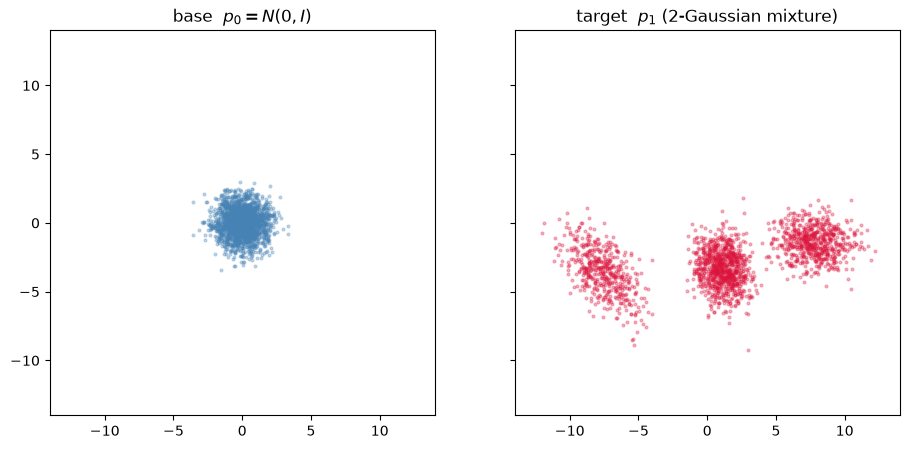

In [24]:
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(2, device=device), torch.eye(2, device=device))

# --- target: 2-component Gaussian mixture from eesi.datasets.GaussianMixture ---
# The mixture draws its weights, means and full covariances once (fixed `seed`)
# and then holds them constant; `sigma` sets how far apart the component means
# are, and `device` keeps all parameters on the GPU when available.
target = GaussianMixture(d=2, n=3, sigma=4, seed=5, device=device)

# Sanity check: draw and scatter samples from each distribution.
x0_vis = base.sample((2000,)).cpu()
x1_vis = target.sample(2000).cpu()

# Symmetric plot limits that comfortably contain both distributions.
LIM = float(torch.cat([x0_vis, x1_vis]).abs().max().ceil()) + 1.0

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
ax[0].scatter(x0_vis[:, 0], x0_vis[:, 1], s=4, alpha=0.3, c="steelblue")
ax[0].set_title("base  $p_0 = N(0, I)$")
ax[1].scatter(x1_vis[:, 0], x1_vis[:, 1], s=4, alpha=0.3, c="crimson")
ax[1].set_title("target  $p_1$ (2-Gaussian mixture)")
for a in ax:
    a.set_aspect("equal"); a.set_xlim(-LIM, LIM); a.set_ylim(-LIM, LIM)
plt.show()

## 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="linear"` uses the straight-line interpolant `x_t = (1-t) x_0 + t x_1`.
- `gamma="quad"` adds the smooth latent-noise schedule `γ(t) = t(1-t)`, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate). Try `gamma="sqrt"` or `gamma="none"`, or `path="trig"`/`"encdec"`.

In [25]:
net_b = TimeMLP(d=2, hidden=256, n_layers=4, activation="relu")
net_s = TimeMLP(d=2, hidden=256, n_layers=4, activation="relu")

model = EESI(
    net_b, net_s,
    d=2,
    path="trig2",   # "linear" | "trig" | "encdec"
    gamma="sin2",    # "none" | "quad" | "sqrt"
    gamma_scale=1.0,
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
#print(model)

## 3. Training loop

Each step draws a fresh minibatch of `(x_0, x_1)` pairs, forms the interpolant
internally, and returns the drift/score losses. We minimise their sum.

In [26]:
n_iters = 5000
batch = 1024

hist_b, hist_s = [], []
for it in range(n_iters):
    x0 = base.sample((batch,))
    x1 = target.sample((batch,))

    losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
    loss = losses["b"] + losses["s"]

    opt.zero_grad()
    loss.backward()
    opt.step()

    hist_b.append(losses["b"].item())
    hist_s.append(losses["s"].item())
    if it % 500 == 0 or it == n_iters - 1:
        print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")

iter    0  loss_b=-0.162  loss_s=+0.005
iter  500  loss_b=-22.648  loss_s=-0.655
iter 1000  loss_b=-22.292  loss_s=-0.694
iter 1500  loss_b=-24.800  loss_s=-0.655
iter 2000  loss_b=-23.423  loss_s=-0.673
iter 2500  loss_b=-23.977  loss_s=-0.680
iter 3000  loss_b=-22.092  loss_s=-0.723
iter 3500  loss_b=-23.328  loss_s=-0.691
iter 4000  loss_b=-23.383  loss_s=-0.650
iter 4500  loss_b=-23.625  loss_s=-0.682
iter 4999  loss_b=-23.190  loss_s=-0.707


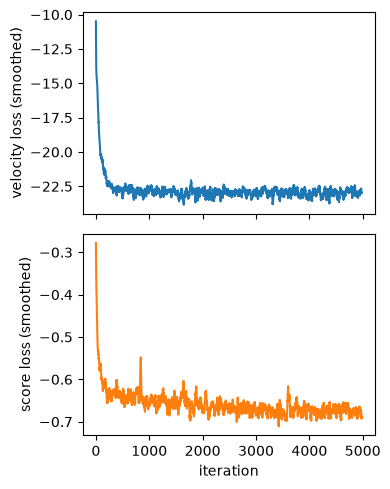

In [27]:
# Training curves (smoothed).
def smooth(v, k=20):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

## 4. Sampling

Map base samples to the target with the model's built-in samplers:

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`
  with Heun's method (drift only).
- `model.sample_sde` integrates the reverse-time **SDE** with Euler–Maruyama,
  using both the drift `b` and the learned score `s` (diffusion `eps`).

In [28]:
# Draw base samples and push them through the model's built-in samplers.
x0 = base.sample((10000,))
gen_ode = model.sample_ode(x0, n_steps=200)           # probability-flow ODE (drift only)
gen_sde = model.sample_sde(x0, n_steps=200, eps=1)  # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(target.sample(10000)).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob — ODE sampler : {target.log_prob(gen_ode).mean():+.3f}")
print(f"mean target log-prob — SDE sampler : {target.log_prob(gen_sde).mean():+.3f}")
print(f"mean target log-prob — true target : {ref:+.3f}")
print(f"mean base log-prob — true target : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")

mean target log-prob — ODE sampler : -4.348
mean target log-prob — SDE sampler : -4.346
mean target log-prob — true target : -4.344
mean base log-prob — true target : -2.851
estimated entropy change : +1.494


## 5. Contour plotting

The analytic target density with generated samples overlaid — the **ODE**
sampler on the left, the **SDE** sampler on the right. Both should populate the
same modes as the target.

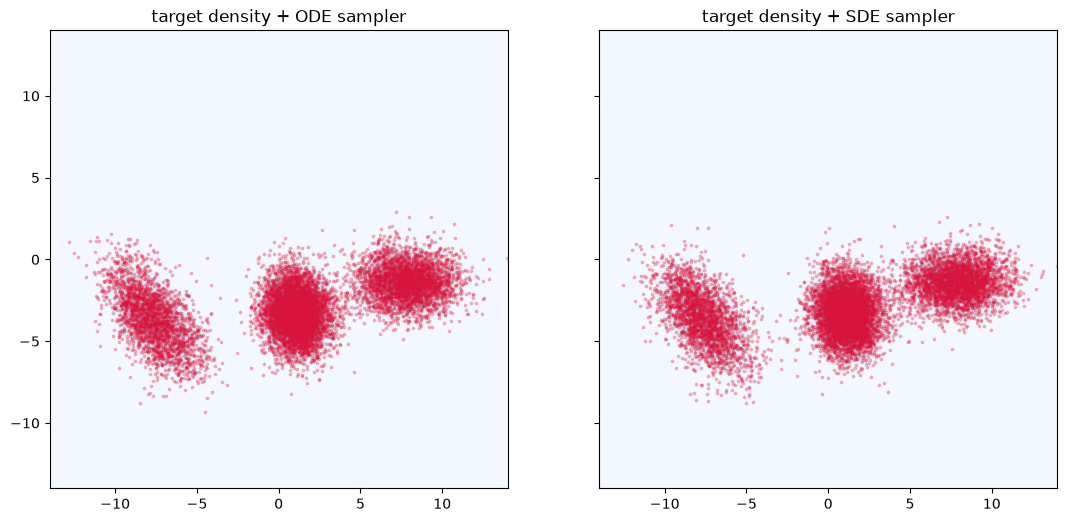

In [29]:
# Evaluate the target density on a grid (on-device), then move to CPU for plotting.
lo, hi, n = -LIM, LIM, 200
xs = torch.linspace(lo, hi, n, device=device)
gx, gy = torch.meshgrid(xs, xs, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1)
dens = target.log_prob(grid).exp().reshape(n, n)
gx, gy, dens = gx.cpu(), gy.cpu(), dens.cpu()

fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for a, samples, title in [(ax[0], gen_ode, "ODE sampler"), (ax[1], gen_sde, "SDE sampler")]:
    s = samples.cpu()
    a.contourf(gx, gy, dens, levels=25, cmap="Blues")
    a.scatter(s[:, 0], s[:, 1], s=3, c="crimson", alpha=0.25)
    a.set_title(f"target density + {title}")
    a.set_aspect("equal"); a.set_xlim(lo, hi); a.set_ylim(lo, hi)
plt.show()

## 6. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{entropy}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`Δentropy(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

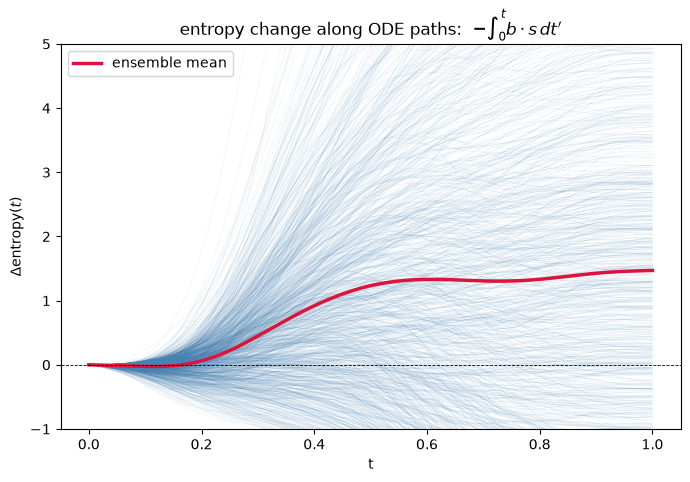

mean Δentropy(1)  (base → target): +1.470


In [30]:
# Trace the running entropy change along many ODE paths.
x0 = base.sample((1000,))
traj, ent_traj, ts = model.sample_sde_entropy_traj(x0, eps=1, n_steps=200)

ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()          # [n_steps+1, B]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
ax.set_ylim(-1,5)
plt.show()

print(f"mean Δentropy(1)  (base → target): {ent_c[-1].mean():+.3f}")

### Next steps

- Swap the interpolant with `path="trig"` or `path="encdec"`, or change the
  latent schedule via `gamma="sqrt"` / `gamma="none"`.
- Vary the SDE diffusion `eps` in `model.sample_sde`, or trade accuracy for speed
  with `method="euler"` in `model.sample_ode`.
- Push the dimension `d` higher and swap in a richer `GaussianMixture` target.